# UAE Gold Trade & Dubai Premium Analysis

This notebook explores the relationship between UAE gold trade flows and the Dubai gold premium/discount relative to international benchmarks (COMEX, LBMA). We combine:
- **Monthly market data** with Dubai & SGE premium estimates
- **UAE bilateral trade flows** by partner country
- **Swiss gold exports to UAE** (monthly, from UN Comtrade)
- **India duty timeline** as a key demand-side driver
- **UAE annual aggregate** import/export volumes

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.facecolor': '#fafafa',
    'font.size': 11,
})

## 1. Load Data

In [33]:
from pathlib import Path

# Set up paths relative to notebook location
NOTEBOOK_DIR = Path('.').resolve()  # cowork/ directory
PROJECT_ROOT = NOTEBOOK_DIR.parent  # premiumDash/
DATA_DIR = PROJECT_ROOT / 'data' / 'gold_trade'

EXCEL = NOTEBOOK_DIR / 'UAE_Gold_Trade_Historical_Data.xlsx'
SWISS_CACHE = DATA_DIR / 'swiss_impex_gold.parquet'

# Verify files exist
assert EXCEL.exists(), f"Excel file not found: {EXCEL}"
assert SWISS_CACHE.exists(), f"Swiss cache not found: {SWISS_CACHE}"

print(f"Notebook dir:  {NOTEBOOK_DIR}")
print(f"Excel file:    {EXCEL} ✓" if EXCEL.exists() else f"Excel file:    {EXCEL} ✗")
print(f"Swiss cache:   {SWISS_CACHE} ✓" if SWISS_CACHE.exists() else f"Swiss cache:   {SWISS_CACHE} ✗")
print()

# Monthly market data (includes Dubai premium, SGE premium, India duty, etc.)
monthly = pd.read_excel(EXCEL, sheet_name='Monthly_Data', parse_dates=['Date'])
monthly = monthly.set_index('Date').sort_index()

# Daily market data
daily = pd.read_excel(EXCEL, sheet_name='Daily_Market_Data', parse_dates=['Date'])
daily = daily.set_index('Date').sort_index()

# UAE trade by partner (annual, USD)
trade_partner = pd.read_excel(EXCEL, sheet_name='UAE_Trade_By_Partner')

# UAE annual aggregate
annual = pd.read_excel(EXCEL, sheet_name='UAE_Annual_Aggregate')

# India duty timeline
india_duty = pd.read_excel(EXCEL, sheet_name='India_Duty_Timeline', parse_dates=['Date'])

# Swiss gold exports to UAE (monthly)
swiss = pd.read_parquet(SWISS_CACHE)
swiss['date'] = pd.to_datetime(swiss['date'])
swiss = swiss.set_index('date').sort_index()

print(f"Monthly market data: {monthly.shape[0]} rows, {monthly.index.min():%Y-%m} to {monthly.index.max():%Y-%m}")
print(f"Daily market data:   {daily.shape[0]} rows")
print(f"Swiss exports:       {swiss.shape[0]} rows, {swiss.index.min():%Y-%m} to {swiss.index.max():%Y-%m}")
print(f"Annual aggregate:    {annual.shape[0]} years")
print(f"Trade partners:      {trade_partner.shape[0]} years x {trade_partner.shape[1]-1} flows")

ValueError: Worksheet named 'UAE_Trade_By_Partner' not found

## 2. Dubai Premium Overview

The Dubai premium/discount reflects the local supply-demand balance for physical gold in the UAE. A **positive premium** means Dubai gold trades above LBMA/COMEX benchmarks — signaling strong regional demand or tight supply. A **discount** signals excess supply or weak local demand.

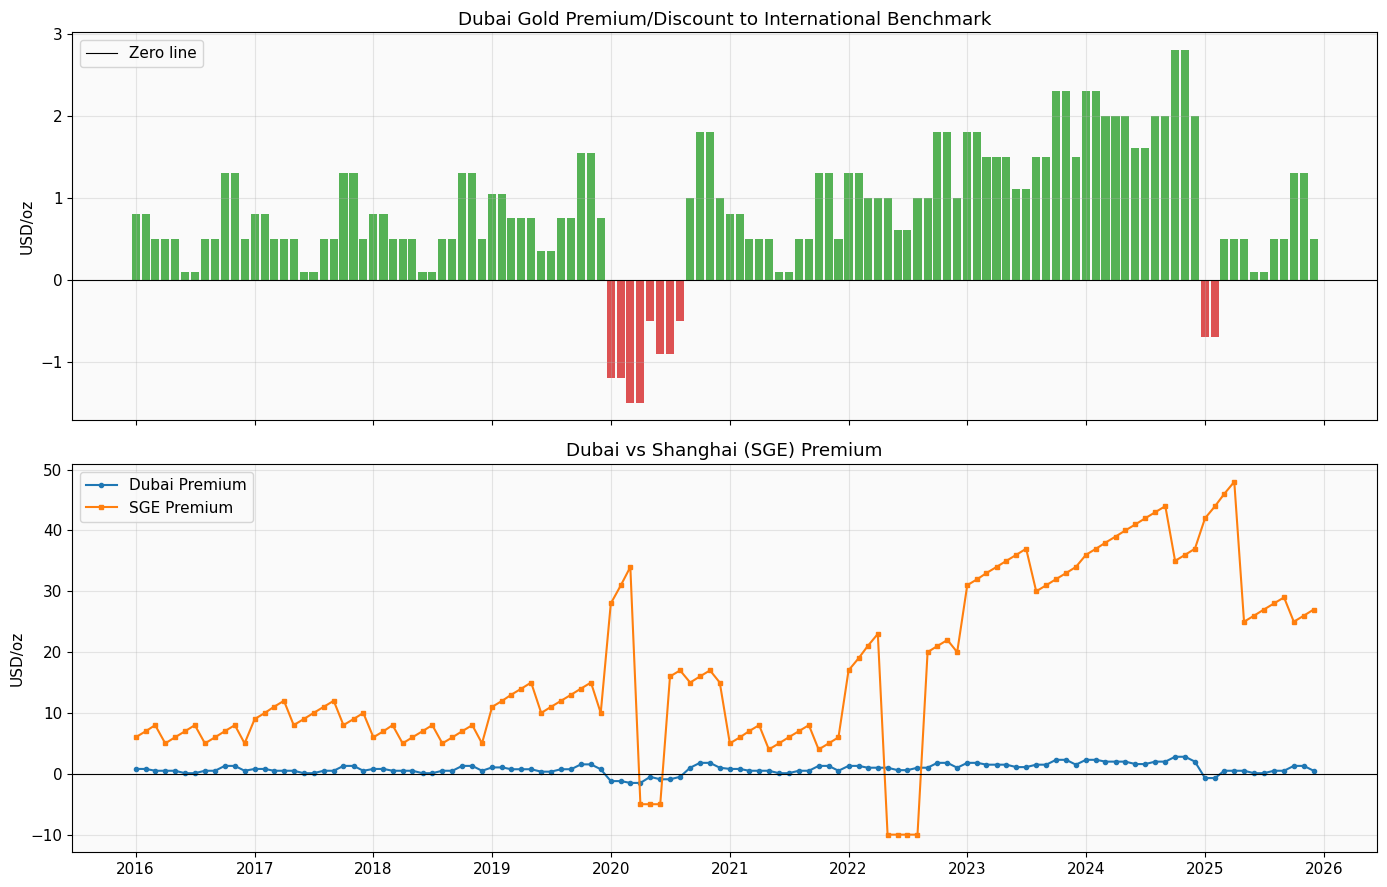


Dubai Premium stats (USD/oz):
count    120.00
mean       0.83
std        0.82
min       -1.50
25%        0.50
50%        0.78
75%        1.30
max        2.80
Name: Dubai_Premium_USD_oz, dtype: float64


In [4]:
prem = monthly[['Dubai_Premium_USD_oz', 'SGE_Premium_USD_oz', 'COMEX_Gold_Close_USD']].dropna(subset=['Dubai_Premium_USD_oz'])

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Dubai premium
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in prem['Dubai_Premium_USD_oz']]
axes[0].bar(prem.index, prem['Dubai_Premium_USD_oz'], width=25, color=colors, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('USD/oz')
axes[0].set_title('Dubai Gold Premium/Discount to International Benchmark')
axes[0].legend(['Zero line'], loc='upper left')

# Dubai vs SGE premium
axes[1].plot(prem.index, prem['Dubai_Premium_USD_oz'], 'o-', label='Dubai Premium', color='#1f77b4', markersize=3)
axes[1].plot(prem.index, prem['SGE_Premium_USD_oz'], 's-', label='SGE Premium', color='#ff7f0e', markersize=3)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('USD/oz')
axes[1].set_title('Dubai vs Shanghai (SGE) Premium')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nDubai Premium stats (USD/oz):")
print(prem['Dubai_Premium_USD_oz'].describe().round(2))

## 3. Dubai Premium vs Gold Price Level

Does the premium widen when gold prices rise (demand surge) or fall (bargain buying)?

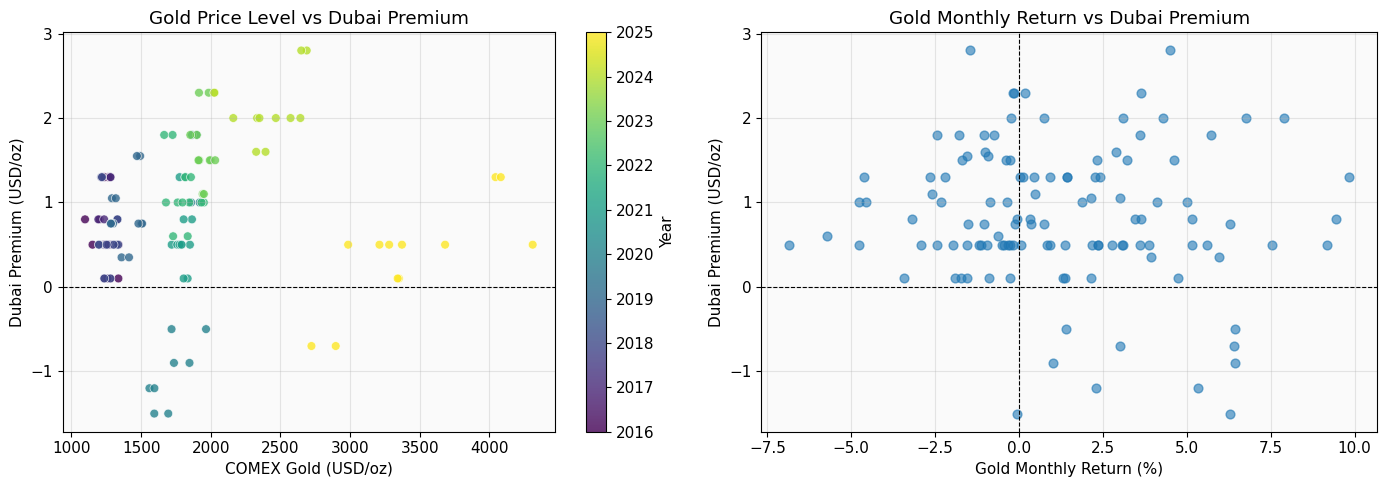

Correlation (gold level vs premium):  0.147
Correlation (gold return vs premium): -0.098


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: gold price vs premium
ax = axes[0]
sc = ax.scatter(prem['COMEX_Gold_Close_USD'], prem['Dubai_Premium_USD_oz'],
                c=prem.index.year, cmap='viridis', s=40, alpha=0.8, edgecolors='white', linewidth=0.5)
plt.colorbar(sc, ax=ax, label='Year')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('COMEX Gold (USD/oz)')
ax.set_ylabel('Dubai Premium (USD/oz)')
ax.set_title('Gold Price Level vs Dubai Premium')

# Gold monthly return vs premium
gold_ret = prem['COMEX_Gold_Close_USD'].pct_change() * 100
ax = axes[1]
ax.scatter(gold_ret, prem['Dubai_Premium_USD_oz'], s=40, alpha=0.6, color='#1f77b4')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Gold Monthly Return (%)')
ax.set_ylabel('Dubai Premium (USD/oz)')
ax.set_title('Gold Monthly Return vs Dubai Premium')

plt.tight_layout()
plt.show()

corr = prem['COMEX_Gold_Close_USD'].corr(prem['Dubai_Premium_USD_oz'])
corr_ret = gold_ret.corr(prem['Dubai_Premium_USD_oz'])
print(f"Correlation (gold level vs premium):  {corr:.3f}")
print(f"Correlation (gold return vs premium): {corr_ret:.3f}")

## 4. Swiss Gold Exports to UAE vs Dubai Premium

Switzerland is a major gold refining hub. Large Swiss exports to UAE indicate **physical supply flowing into Dubai**, which should compress premiums. Conversely, a spike in the Dubai premium may attract more Swiss supply.

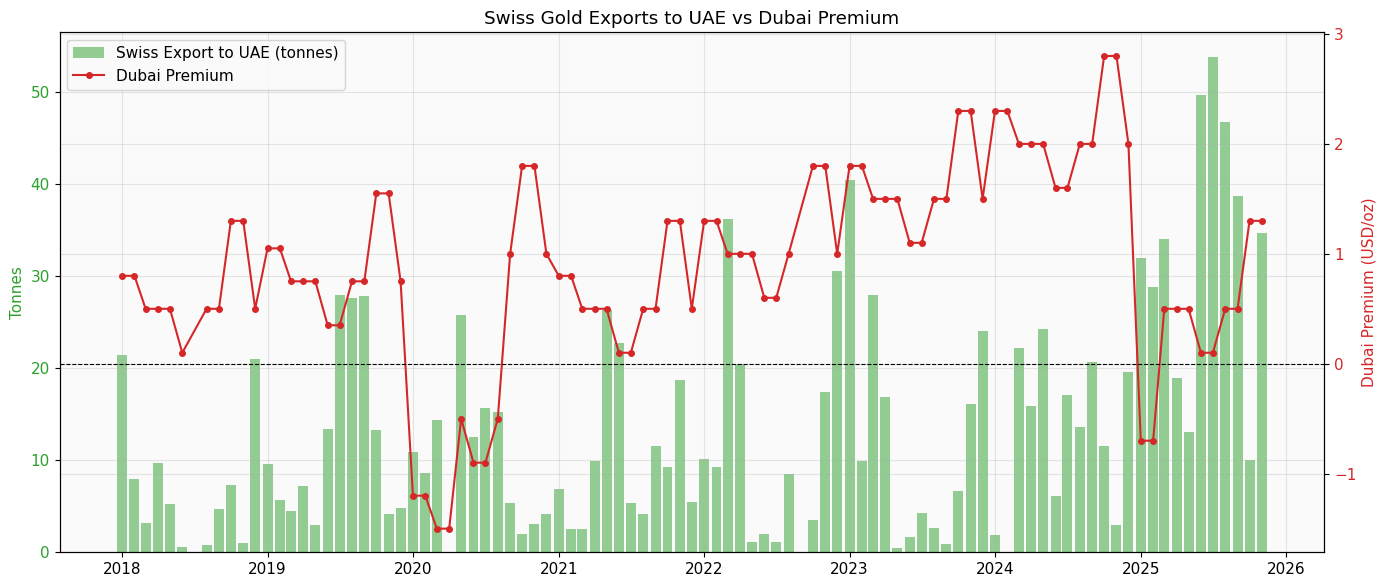

Correlation: Swiss export volume vs Dubai premium
  Contemporaneous: -0.139
  Lag 1m (premium leads supply): -0.081
  Lag 2m (premium leads supply): 0.003
  Lag 3m (premium leads supply): 0.019


In [26]:
# Merge Swiss export volumes with Dubai premium (monthly)
swiss_m = swiss[['net_weight_tonnes', 'value_usd']].copy()
swiss_m.columns = ['Swiss_Export_Tonnes', 'Swiss_Export_USD']

merged = monthly[['Dubai_Premium_USD_oz', 'SGE_Premium_USD_oz', 'COMEX_Gold_Close_USD']].join(swiss_m, how='inner')
merged = merged.dropna(subset=['Dubai_Premium_USD_oz'])

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(merged.index, merged['Swiss_Export_Tonnes'], width=25, alpha=0.5, color='#2ca02c', label='Swiss Export to UAE (tonnes)')
ax1.set_ylabel('Tonnes', color='#2ca02c')
ax1.tick_params(axis='y', labelcolor='#2ca02c')

ax2 = ax1.twinx()
ax2.plot(merged.index, merged['Dubai_Premium_USD_oz'], 'o-', color='#d62728', markersize=4, label='Dubai Premium')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Dubai Premium (USD/oz)', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Swiss Gold Exports to UAE vs Dubai Premium')
plt.tight_layout()
plt.show()

# Lagged correlation: does Swiss supply respond to premium?
print("Correlation: Swiss export volume vs Dubai premium")
for lag in [0, 1, 2, 3]:
    c = merged['Swiss_Export_Tonnes'].corr(merged['Dubai_Premium_USD_oz'].shift(lag))
    label = f"  Lag {lag}m (premium leads supply)" if lag > 0 else "  Contemporaneous"
    print(f"{label}: {c:.3f}")

## 5. India Duty & Dubai Premium

India is the largest destination for UAE gold exports. Changes in India's import duty directly affect smuggling incentives and legitimate demand routed through Dubai, which impacts the Dubai premium.

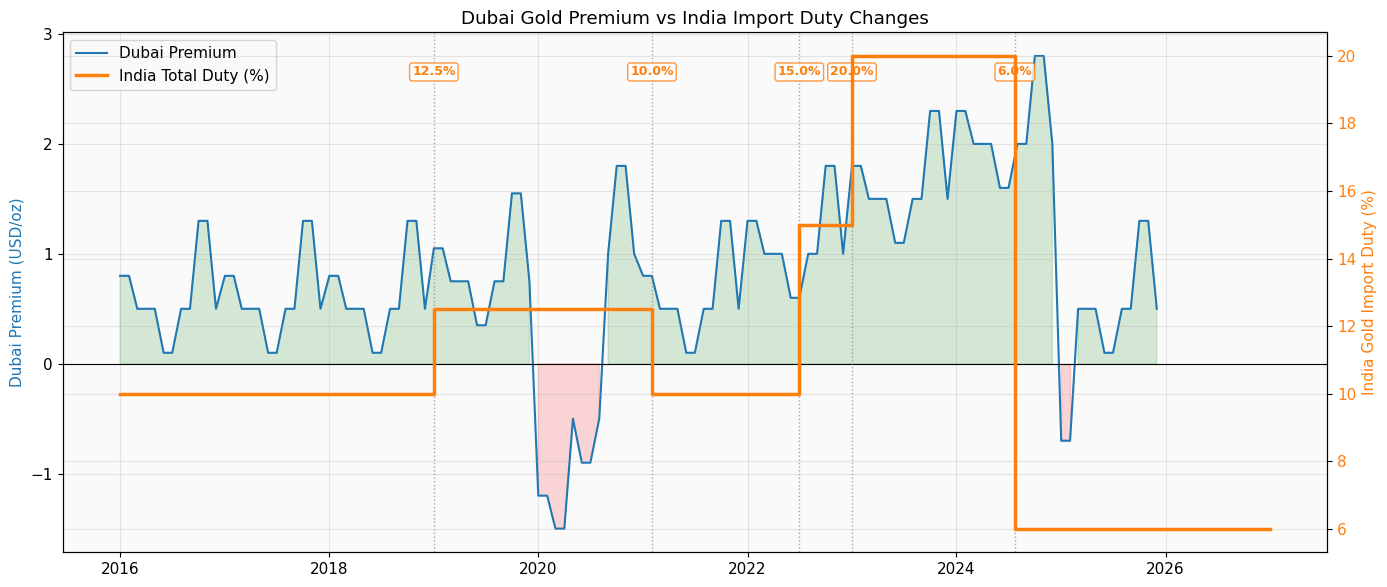


Dubai Premium by India Duty Regime:
                           mean  median   std  count
India_Gold_Total_Duty_Pct                           
6.0                        0.94    0.50  1.08     17
10.0                       0.66    0.50  0.38     53
12.5                       0.34    0.75  1.05     25
15.0                       1.20    1.00  0.49      6
20.0                       1.75    1.60  0.38     19


In [27]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Monthly premium
prem_plot = monthly[['Dubai_Premium_USD_oz']].dropna()
ax1.plot(prem_plot.index, prem_plot['Dubai_Premium_USD_oz'], '-', color='#1f77b4', linewidth=1.5, label='Dubai Premium')
ax1.fill_between(prem_plot.index, 0, prem_plot['Dubai_Premium_USD_oz'],
                 where=prem_plot['Dubai_Premium_USD_oz'] >= 0, alpha=0.15, color='green')
ax1.fill_between(prem_plot.index, 0, prem_plot['Dubai_Premium_USD_oz'],
                 where=prem_plot['Dubai_Premium_USD_oz'] < 0, alpha=0.15, color='red')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_ylabel('Dubai Premium (USD/oz)', color='#1f77b4')

# India duty step function
ax2 = ax1.twinx()
duty = india_duty.set_index('Date')['India_Gold_Total_Duty_Pct']
# Extend to present for step plot
duty_ext = duty.copy()
duty_ext.loc[pd.Timestamp('2026-12-31')] = duty_ext.iloc[-1]
ax2.step(duty_ext.index, duty_ext.values, where='post', color='#ff7f0e', linewidth=2.5, label='India Total Duty (%)')
ax2.set_ylabel('India Gold Import Duty (%)', color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# Annotate duty changes
for i in range(1, len(india_duty)):
    prev = india_duty.iloc[i-1]['India_Gold_Total_Duty_Pct']
    curr = india_duty.iloc[i]['India_Gold_Total_Duty_Pct']
    if curr != prev:
        dt = india_duty.iloc[i]['Date']
        ax1.axvline(dt, color='gray', linewidth=1, linestyle=':', alpha=0.7)
        ax1.annotate(f'{curr}%', xy=(dt, ax1.get_ylim()[1]*0.9),
                     fontsize=9, color='#ff7f0e', fontweight='bold',
                     ha='center', va='top',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#ff7f0e', alpha=0.8))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Dubai Gold Premium vs India Import Duty Changes')
plt.tight_layout()
plt.show()

# Regime analysis
prem_duty = monthly[['Dubai_Premium_USD_oz', 'India_Gold_Total_Duty_Pct']].dropna()
print("\nDubai Premium by India Duty Regime:")
print(prem_duty.groupby('India_Gold_Total_Duty_Pct')['Dubai_Premium_USD_oz'].agg(['mean', 'median', 'std', 'count']).round(2))

## 6. UAE Annual Trade Flows & Premium Regime

How do aggregate UAE gold import/export volumes relate to premium levels?

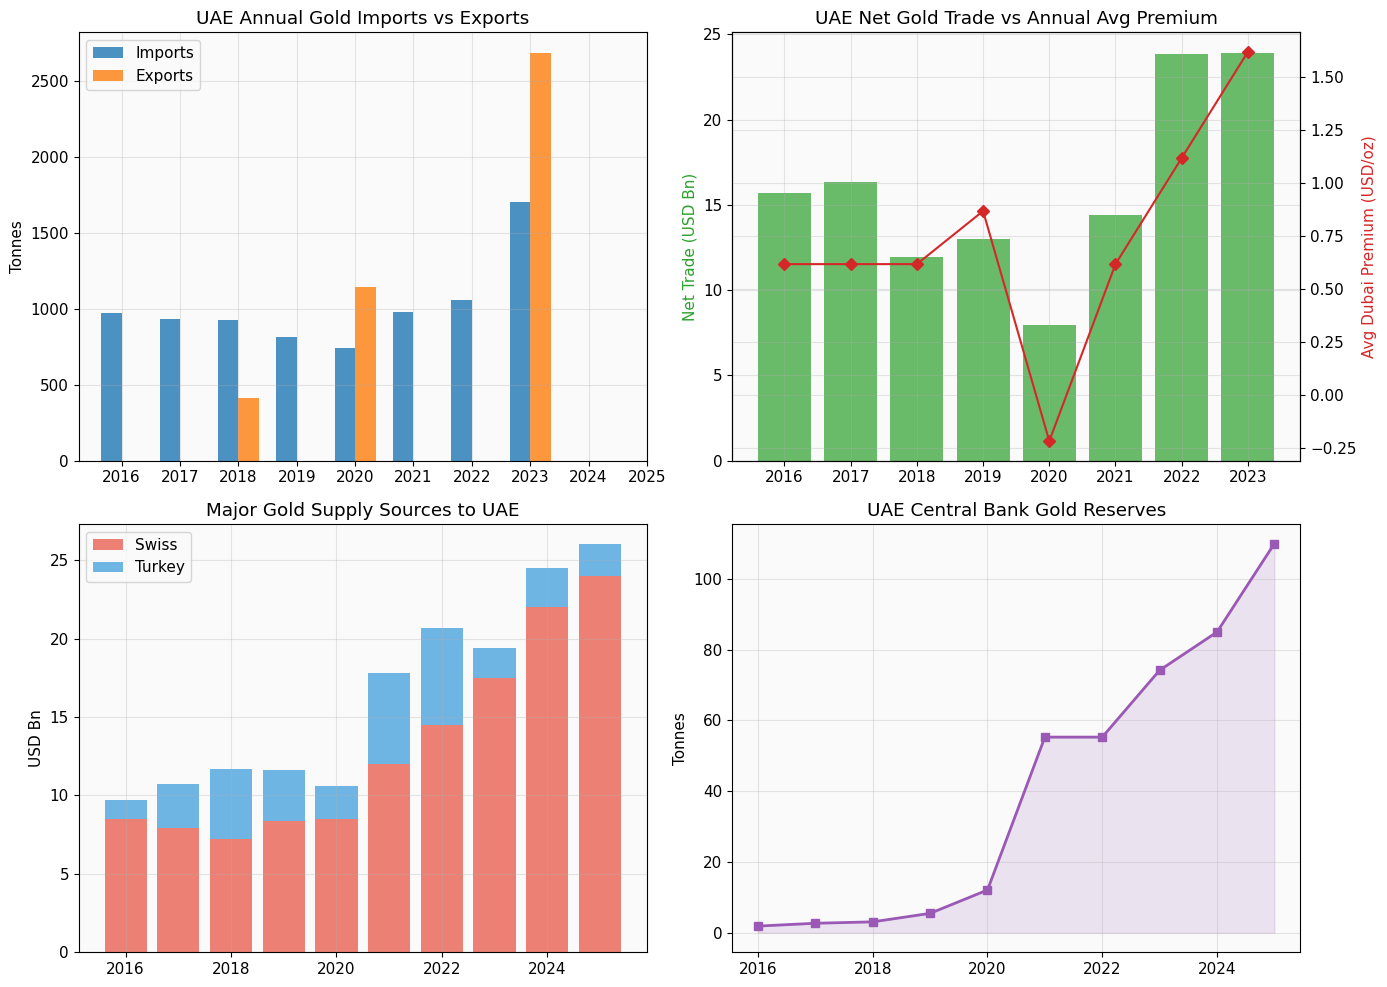

In [8]:
# Compute annual average premium from monthly data
annual_prem = monthly['Dubai_Premium_USD_oz'].resample('YE').mean().reset_index()
annual_prem['Year'] = annual_prem['Date'].dt.year
ann = annual.merge(annual_prem[['Year', 'Dubai_Premium_USD_oz']], on='Year', how='left')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Import vs Export tonnes
ax = axes[0, 0]
x = np.arange(len(ann))
w = 0.35
ax.bar(x - w/2, ann['Import_Tonnes'], w, label='Imports', color='#1f77b4', alpha=0.8)
ax.bar(x + w/2, ann['Export_Tonnes'], w, label='Exports', color='#ff7f0e', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ann['Year'])
ax.set_ylabel('Tonnes')
ax.set_title('UAE Annual Gold Imports vs Exports')
ax.legend()

# Net trade vs average premium
ax = axes[0, 1]
valid = ann.dropna(subset=['Net_Trade_Value_USD', 'Dubai_Premium_USD_oz'])
ax.bar(valid['Year'], valid['Net_Trade_Value_USD'] / 1e9, color='#2ca02c', alpha=0.7)
ax.set_ylabel('Net Trade (USD Bn)', color='#2ca02c')
ax2 = ax.twinx()
ax2.plot(valid['Year'], valid['Dubai_Premium_USD_oz'], 'D-', color='#d62728', markersize=6)
ax2.set_ylabel('Avg Dubai Premium (USD/oz)', color='#d62728')
ax.set_title('UAE Net Gold Trade vs Annual Avg Premium')

# Swiss + Turkey supply to UAE
ax = axes[1, 0]
ax.bar(ann['Year'], ann['Swiss_Gold_Export_to_UAE_USD_Bn'], label='Swiss', color='#e74c3c', alpha=0.7)
ax.bar(ann['Year'], ann['Turkey_Gold_Export_to_UAE_USD_Bn'],
       bottom=ann['Swiss_Gold_Export_to_UAE_USD_Bn'], label='Turkey', color='#3498db', alpha=0.7)
ax.set_ylabel('USD Bn')
ax.set_title('Major Gold Supply Sources to UAE')
ax.legend()

# UAE CB reserves
ax = axes[1, 1]
ax.plot(ann['Year'], ann['UAE_CB_Gold_Reserves_Tonnes'], 's-', color='#9b59b6', linewidth=2, markersize=6)
ax.fill_between(ann['Year'], ann['UAE_CB_Gold_Reserves_Tonnes'], alpha=0.15, color='#9b59b6')
ax.set_ylabel('Tonnes')
ax.set_title('UAE Central Bank Gold Reserves')

plt.tight_layout()
plt.show()

## 7. Trade Partner Composition & the Premium Signal

Where UAE sources gold (imports) and where it sends gold (exports) reveals the arbitrage channels that drive the premium. Heavy African imports suggest artisanal supply at discount; heavy India/Switzerland exports suggest demand-pull at premium.

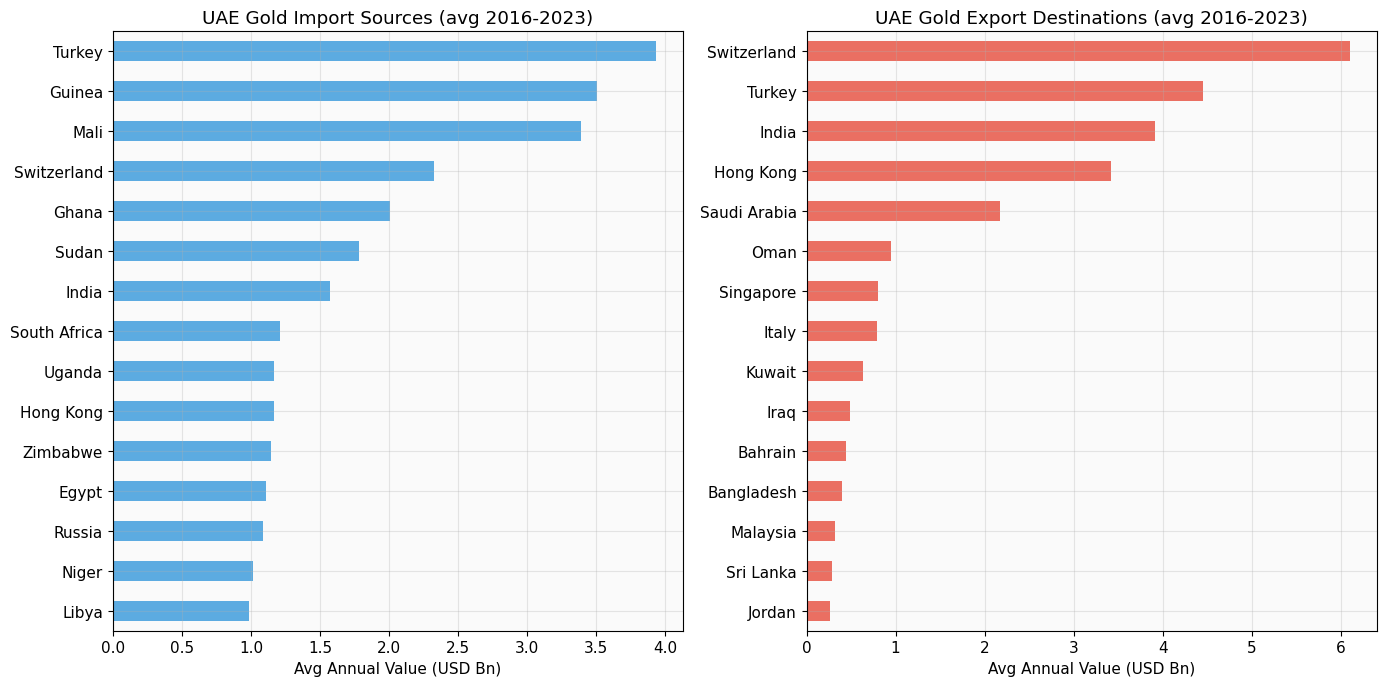

In [9]:
# Separate imports and exports
imp_cols = [c for c in trade_partner.columns if c.startswith('Imp_')]
exp_cols = [c for c in trade_partner.columns if c.startswith('Exp_')]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Top import sources (average across years)
imp_avg = trade_partner[imp_cols].mean().sort_values(ascending=True) / 1e9
imp_avg.index = [c.replace('Imp_', '').replace('_', ' ') for c in imp_avg.index]
imp_avg.plot(kind='barh', ax=axes[0], color='#3498db', alpha=0.8)
axes[0].set_xlabel('Avg Annual Value (USD Bn)')
axes[0].set_title('UAE Gold Import Sources (avg 2016-2023)')

# Top export destinations
exp_avg = trade_partner[exp_cols].mean().sort_values(ascending=True) / 1e9
exp_avg.index = [c.replace('Exp_', '').replace('_', ' ') for c in exp_avg.index]
exp_avg.plot(kind='barh', ax=axes[1], color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Avg Annual Value (USD Bn)')
axes[1].set_title('UAE Gold Export Destinations (avg 2016-2023)')

plt.tight_layout()
plt.show()

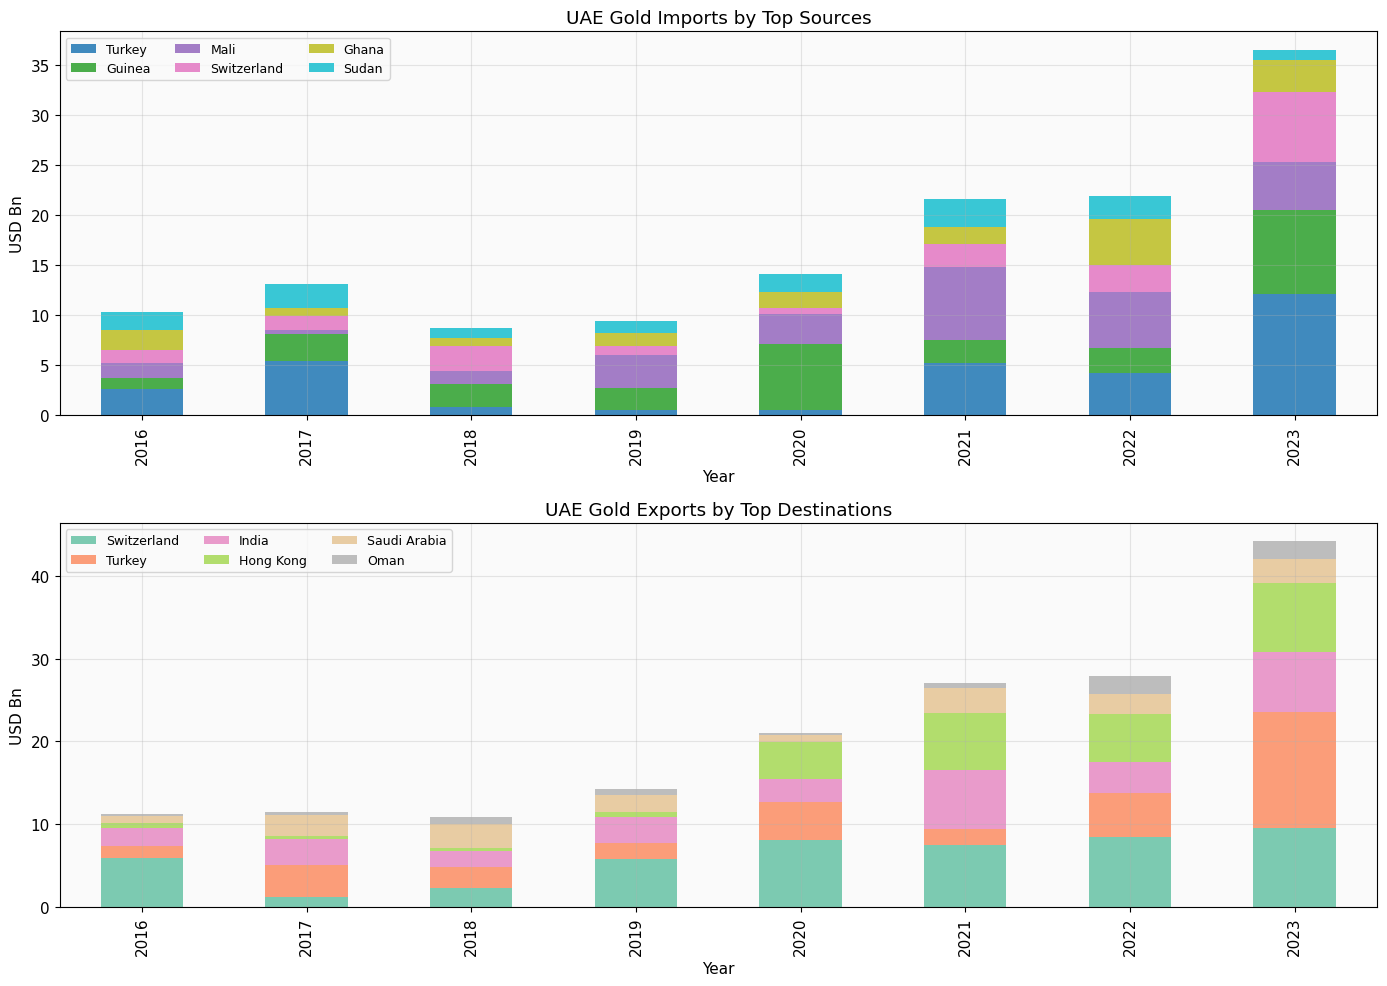

In [10]:
# Trade flow evolution over time — stacked area for top partners
top_imp = trade_partner[imp_cols].mean().nlargest(6).index.tolist()
top_exp = trade_partner[exp_cols].mean().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Imports stacked
imp_data = trade_partner[['Year'] + top_imp].set_index('Year') / 1e9
imp_data.columns = [c.replace('Imp_', '').replace('_', ' ') for c in imp_data.columns]
imp_data.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', alpha=0.85)
axes[0].set_ylabel('USD Bn')
axes[0].set_title('UAE Gold Imports by Top Sources')
axes[0].legend(loc='upper left', ncol=3, fontsize=9)

# Exports stacked
exp_data = trade_partner[['Year'] + top_exp].set_index('Year') / 1e9
exp_data.columns = [c.replace('Exp_', '').replace('_', ' ') for c in exp_data.columns]
exp_data.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', alpha=0.85)
axes[1].set_ylabel('USD Bn')
axes[1].set_title('UAE Gold Exports by Top Destinations')
axes[1].legend(loc='upper left', ncol=3, fontsize=9)

plt.tight_layout()
plt.show()

## 8. Swiss Monthly Supply & Implied Pricing

Using Swiss export data (volume in tonnes + value in USD), we can compute an **implied average price per oz** for Swiss gold shipped to UAE and compare it to COMEX — the difference approximates the effective premium/discount at which physical gold is flowing.

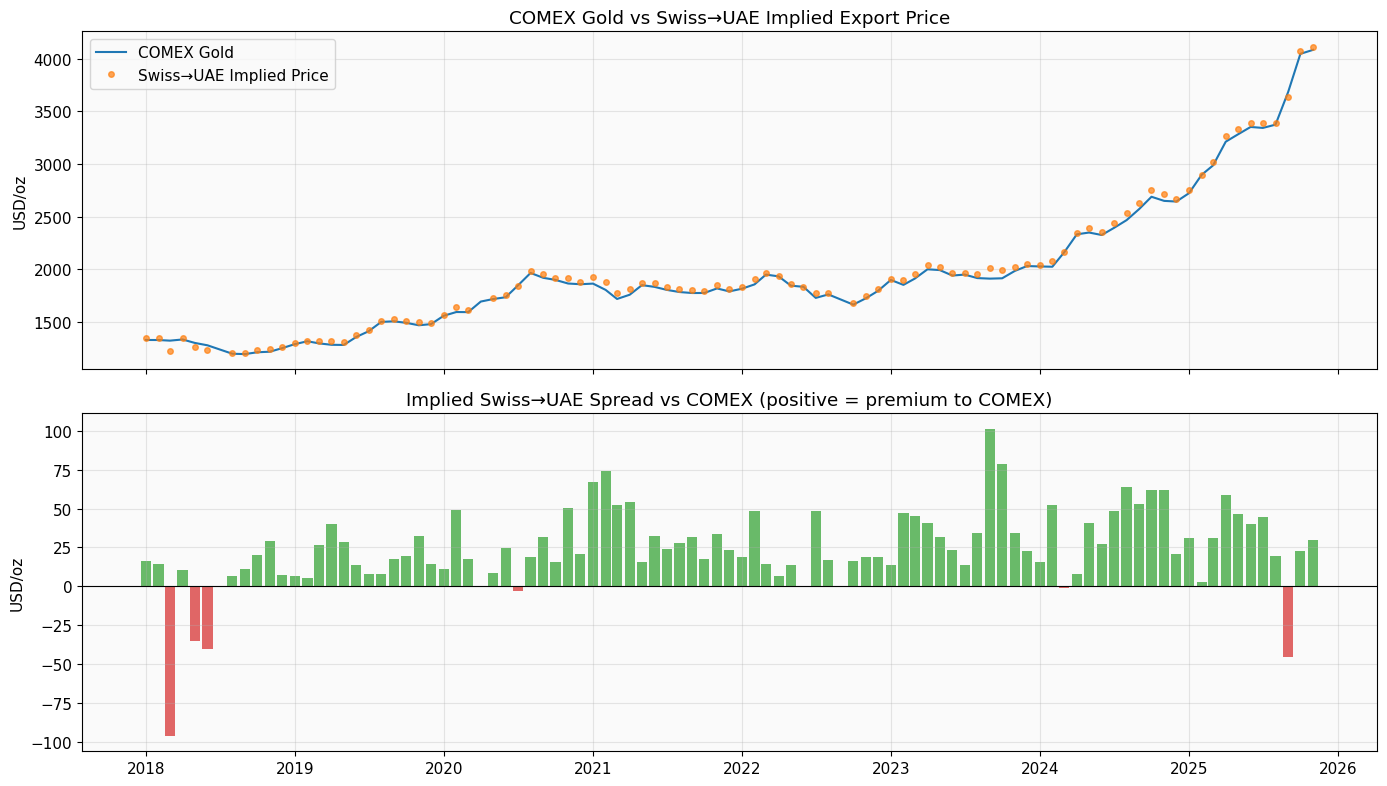


Implied spread stats (USD/oz):
count    93.00
mean       inf
std        NaN
min     -96.04
25%      13.84
50%      22.81
75%      40.44
max        inf
Name: implied_spread, dtype: float64


In [11]:
# Compute implied price per oz from Swiss trade data
TROY_OZ_PER_TONNE = 32150.7465

swiss_price = swiss.copy()
swiss_price['oz'] = swiss_price['net_weight_tonnes'] * TROY_OZ_PER_TONNE
swiss_price['implied_price_usd_oz'] = swiss_price['value_usd'] / swiss_price['oz']

# Join with COMEX gold
comex_m = monthly[['COMEX_Gold_Close_USD']]
swiss_comp = swiss_price[['net_weight_tonnes', 'implied_price_usd_oz']].join(comex_m, how='inner')
swiss_comp['implied_spread'] = swiss_comp['implied_price_usd_oz'] - swiss_comp['COMEX_Gold_Close_USD']
swiss_comp = swiss_comp.dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Implied price vs COMEX
ax = axes[0]
ax.plot(swiss_comp.index, swiss_comp['COMEX_Gold_Close_USD'], label='COMEX Gold', color='#1f77b4')
ax.plot(swiss_comp.index, swiss_comp['implied_price_usd_oz'], 'o', label='Swiss→UAE Implied Price',
        color='#ff7f0e', markersize=4, alpha=0.7)
ax.set_ylabel('USD/oz')
ax.set_title('COMEX Gold vs Swiss→UAE Implied Export Price')
ax.legend()

# Implied spread
ax = axes[1]
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in swiss_comp['implied_spread']]
ax.bar(swiss_comp.index, swiss_comp['implied_spread'], width=25, color=colors, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('USD/oz')
ax.set_title('Implied Swiss→UAE Spread vs COMEX (positive = premium to COMEX)')

plt.tight_layout()
plt.show()

print(f"\nImplied spread stats (USD/oz):")
print(swiss_comp['implied_spread'].describe().round(2))

## 9. Macro Drivers Dashboard

How do macro variables (DXY, VIX, US yields, oil) relate to the Dubai premium? These can shift risk appetite and physical gold demand in the Middle East and India.

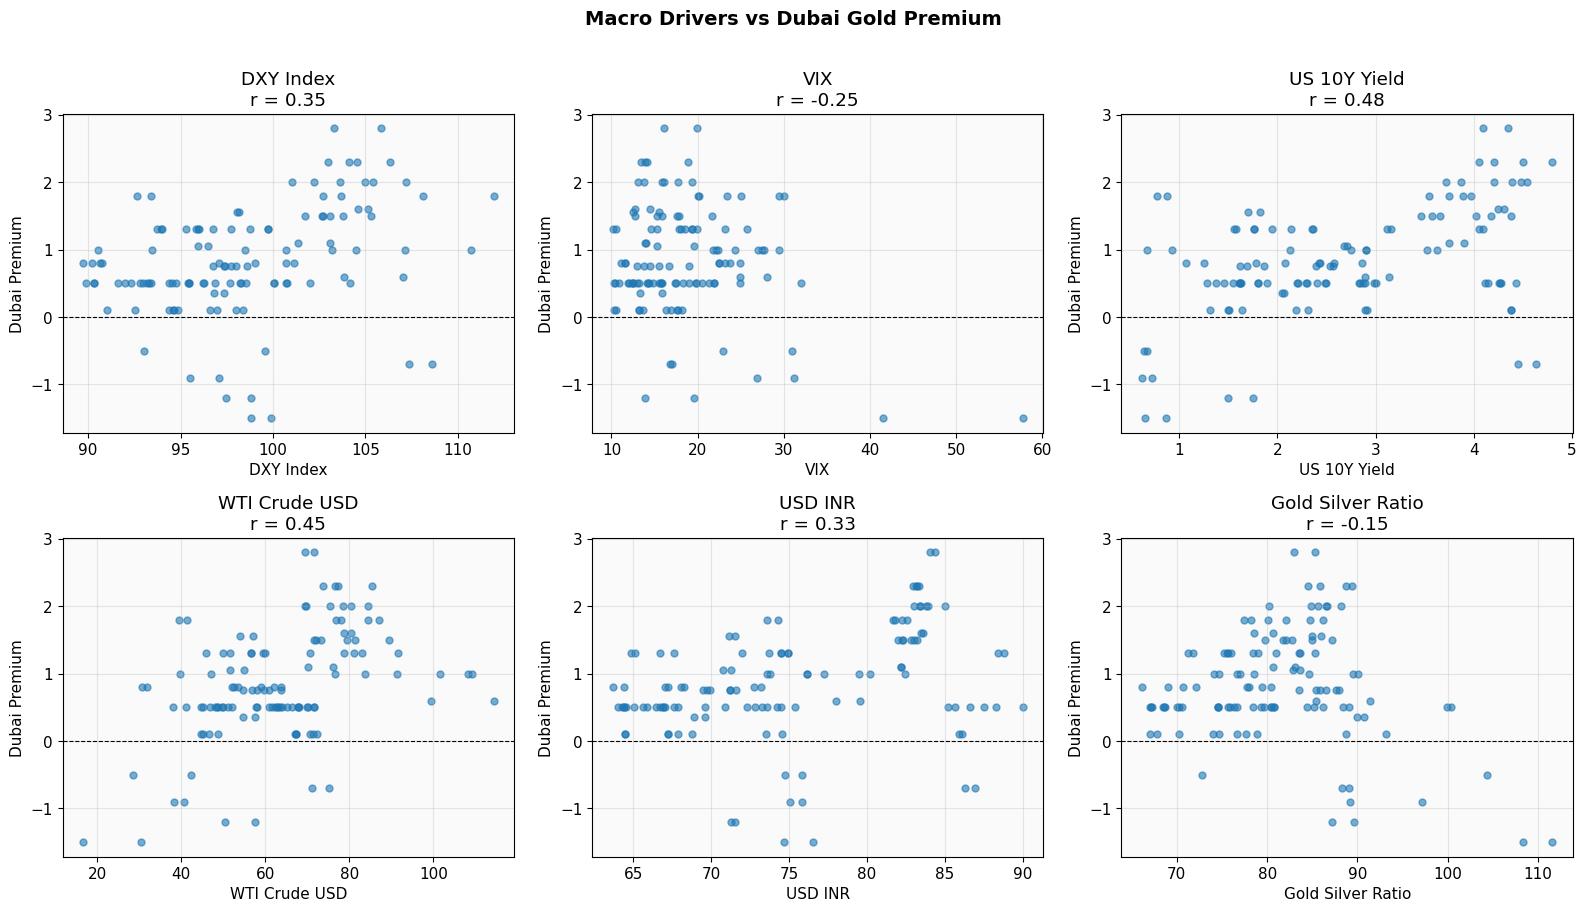

In [12]:
macro_cols = ['DXY_Index', 'VIX', 'US_10Y_Yield', 'WTI_Crude_USD', 'USD_INR', 'Gold_Silver_Ratio']
prem_macro = monthly[['Dubai_Premium_USD_oz'] + macro_cols].dropna(subset=['Dubai_Premium_USD_oz'])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(macro_cols):
    ax = axes[i // 3, i % 3]
    valid = prem_macro[[col, 'Dubai_Premium_USD_oz']].dropna()
    ax.scatter(valid[col], valid['Dubai_Premium_USD_oz'], s=25, alpha=0.6, color='#1f77b4')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    corr = valid[col].corr(valid['Dubai_Premium_USD_oz'])
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('Dubai Premium')
    ax.set_title(f'{col.replace("_", " ")}\nr = {corr:.2f}')

plt.suptitle('Macro Drivers vs Dubai Gold Premium', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Correlation Matrix — Premium Drivers

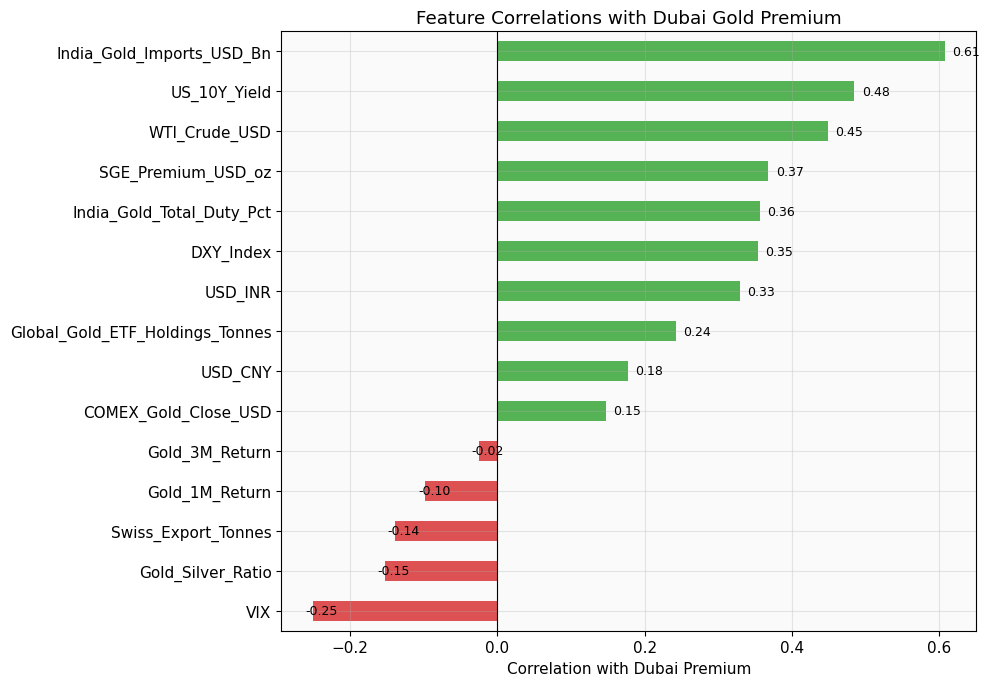

In [13]:
# Build a comprehensive feature set
feat = monthly[['Dubai_Premium_USD_oz', 'SGE_Premium_USD_oz', 'COMEX_Gold_Close_USD',
                'DXY_Index', 'VIX', 'US_10Y_Yield', 'WTI_Crude_USD',
                'USD_INR', 'USD_CNY', 'Gold_Silver_Ratio',
                'India_Gold_Imports_USD_Bn', 'India_Gold_Total_Duty_Pct',
                'Global_Gold_ETF_Holdings_Tonnes']].copy()

# Add Swiss export volume
feat = feat.join(swiss_m['Swiss_Export_Tonnes'])

# Gold momentum
feat['Gold_1M_Return'] = monthly['COMEX_Gold_Close_USD'].pct_change() * 100
feat['Gold_3M_Return'] = monthly['COMEX_Gold_Close_USD'].pct_change(3) * 100

corr_cols = feat.columns[feat.columns != 'Dubai_Premium_USD_oz']
corr_vals = feat[corr_cols].corrwith(feat['Dubai_Premium_USD_oz']).dropna().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in corr_vals]
corr_vals.plot(kind='barh', ax=ax, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Dubai Premium')
ax.set_title('Feature Correlations with Dubai Gold Premium')
for i, v in enumerate(corr_vals):
    ax.text(v + 0.01 * np.sign(v), i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Seasonal Patterns

Is there a seasonal pattern in the Dubai premium (e.g., Diwali demand, Q4 wedding season in India, Ramadan)?

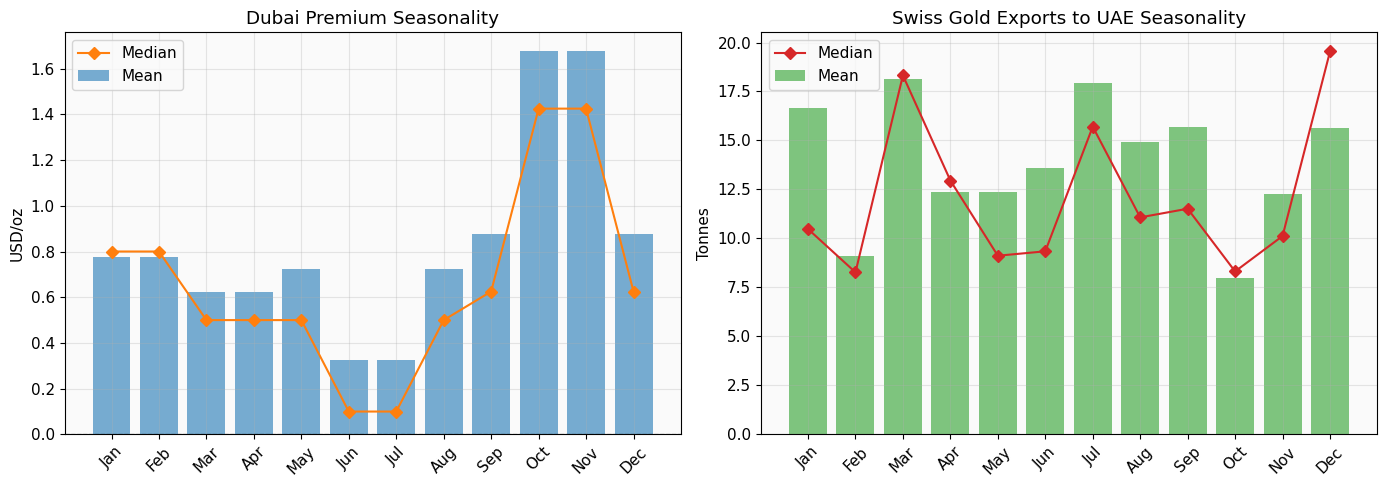

In [14]:
prem_seasonal = monthly[['Dubai_Premium_USD_oz']].dropna().copy()
prem_seasonal['Month'] = prem_seasonal.index.month

swiss_seasonal = swiss[['net_weight_tonnes']].copy()
swiss_seasonal['Month'] = swiss_seasonal.index.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Premium seasonality
ax = axes[0]
seasonal_stats = prem_seasonal.groupby('Month')['Dubai_Premium_USD_oz'].agg(['mean', 'median', 'std'])
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(range(1, 13), seasonal_stats['mean'], alpha=0.6, color='#1f77b4', label='Mean')
ax.plot(range(1, 13), seasonal_stats['median'], 'D-', color='#ff7f0e', label='Median')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months, rotation=45)
ax.set_ylabel('USD/oz')
ax.set_title('Dubai Premium Seasonality')
ax.legend()

# Swiss export seasonality
ax = axes[1]
swiss_stats = swiss_seasonal.groupby('Month')['net_weight_tonnes'].agg(['mean', 'median'])
ax.bar(range(1, 13), swiss_stats['mean'], alpha=0.6, color='#2ca02c', label='Mean')
ax.plot(range(1, 13), swiss_stats['median'], 'D-', color='#d62728', label='Median')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months, rotation=45)
ax.set_ylabel('Tonnes')
ax.set_title('Swiss Gold Exports to UAE Seasonality')
ax.legend()

plt.tight_layout()
plt.show()

## 12. Dubai as a Gold Hub: Import Source Diversification

How has the composition of UAE gold imports shifted over time? A changing source mix can reveal new supply corridors and their effect on the premium.

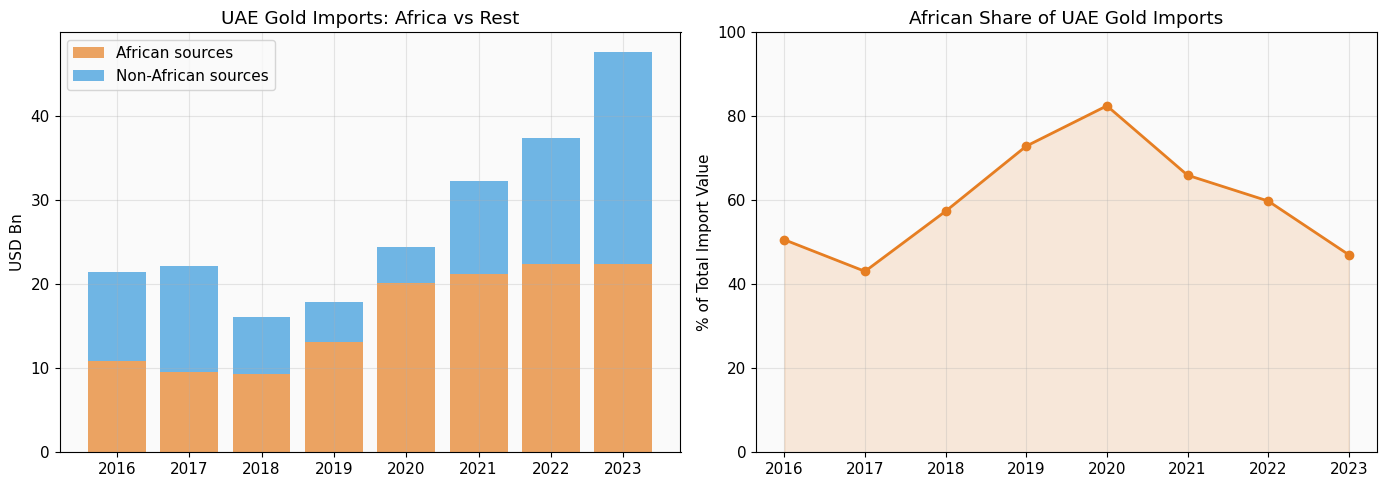


African share of UAE gold imports by year:
Year
2016    50.6
2017    43.1
2018    57.4
2019    72.9
2020    82.5
2021    66.0
2022    59.8
2023    47.0
Name: Africa_Share, dtype: float64


In [15]:
# African imports vs non-African
africa_cols = [c for c in imp_cols if any(a in c for a in ['Guinea', 'Mali', 'Ghana', 'Sudan', 'Uganda', 'Zimbabwe', 'Niger', 'Libya', 'Egypt', 'South_Africa'])]
non_africa_cols = [c for c in imp_cols if c not in africa_cols]

tp = trade_partner.set_index('Year')
tp['Africa_Imports'] = tp[africa_cols].sum(axis=1)
tp['Non_Africa_Imports'] = tp[non_africa_cols].sum(axis=1)
tp['Africa_Share'] = tp['Africa_Imports'] / (tp['Africa_Imports'] + tp['Non_Africa_Imports']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(tp.index, tp['Africa_Imports'] / 1e9, label='African sources', color='#e67e22', alpha=0.7)
ax.bar(tp.index, tp['Non_Africa_Imports'] / 1e9, bottom=tp['Africa_Imports'] / 1e9,
       label='Non-African sources', color='#3498db', alpha=0.7)
ax.set_ylabel('USD Bn')
ax.set_title('UAE Gold Imports: Africa vs Rest')
ax.legend()

ax = axes[1]
ax.plot(tp.index, tp['Africa_Share'], 'o-', color='#e67e22', linewidth=2, markersize=6)
ax.fill_between(tp.index, tp['Africa_Share'], alpha=0.15, color='#e67e22')
ax.set_ylabel('% of Total Import Value')
ax.set_title('African Share of UAE Gold Imports')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\nAfrican share of UAE gold imports by year:")
print(tp['Africa_Share'].round(1))

## 13. Dubai Premium Regime Analysis

Classify months into premium/discount regimes and examine what market conditions characterize each.

In [31]:
regime = monthly.copy()
regime = regime.dropna(subset=['Dubai_Premium_USD_oz'])
regime['Regime'] = pd.qcut(regime['Dubai_Premium_USD_oz'],q=5, duplicates='drop')

compare_cols = ['COMEX_Gold_Close_USD', 'DXY_Index', 'VIX', 'US_10Y_Yield',
                'USD_INR', 'Gold_Silver_Ratio', 'India_Gold_Total_Duty_Pct']

regime_summary = regime.groupby('Regime')[compare_cols].agg(['mean', 'median']).round(2)

print("Market conditions by Dubai premium regime:")
print("="*80)
for col in compare_cols:
    print(f"\n{col}:")
    for r in regime['Regime'].cat.categories:
        subset = regime[regime['Regime'] == r]
        n = len(subset)
        m = subset[col].mean()
        md = subset[col].median()
        print(f"  {r}  n={n:3d}  mean={m:10.2f}  median={md:10.2f}")

print(f"\n\nRegime distribution:")
print(regime['Regime'].value_counts())

Market conditions by Dubai premium regime:

COMEX_Gold_Close_USD:
  (-1.501, 0.5]  n= 52  mean=   1814.83  median=   1486.62
  (0.5, 1.0]  n= 24  mean=   1572.00  median=   1593.01
  (1.0, 1.5]  n= 22  mean=   1870.94  median=   1838.62
  (1.5, 2.8]  n= 22  mean=   2109.76  median=   2026.62

DXY_Index:
  (-1.501, 0.5]  n= 52  mean=     96.43  median=     96.22
  (0.5, 1.0]  n= 24  mean=     98.53  median=     98.23
  (1.0, 1.5]  n= 22  mean=     98.80  median=     98.25
  (1.5, 2.8]  n= 22  mean=    103.18  median=    103.88

VIX:
  (-1.501, 0.5]  n= 52  mean=     18.24  median=     16.09
  (0.5, 1.0]  n= 24  mean=     20.77  median=     22.41
  (1.0, 1.5]  n= 22  mean=     17.10  median=     17.73
  (1.5, 2.8]  n= 22  mean=     17.98  median=     16.13

US_10Y_Yield:
  (-1.501, 0.5]  n= 52  mean=      2.36  median=      2.20
  (0.5, 1.0]  n= 24  mean=      2.27  median=      2.42
  (1.0, 1.5]  n= 22  mean=      3.01  median=      3.14
  (1.5, 2.8]  n= 22  mean=      3.64  median=    

## 14. India Gold Imports & the Dubai-India Corridor

India is the dominant export destination for UAE gold. Higher Indian import demand should support the Dubai premium.

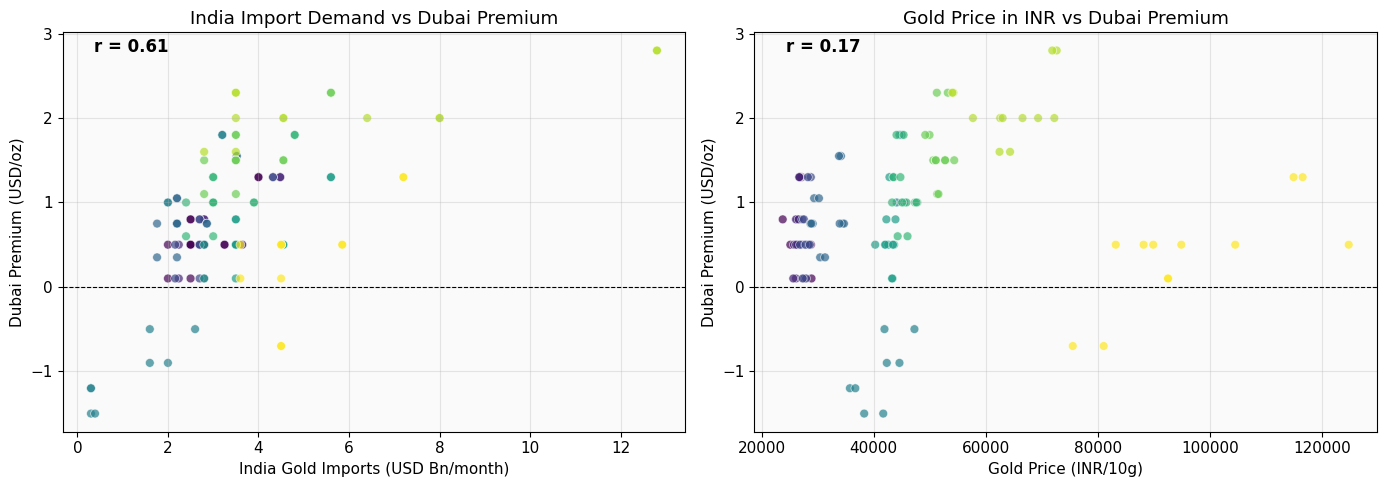

In [17]:
india = monthly[['Dubai_Premium_USD_oz', 'India_Gold_Imports_USD_Bn', 'Gold_INR_per_10g']].dropna(subset=['Dubai_Premium_USD_oz', 'India_Gold_Imports_USD_Bn'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(india['India_Gold_Imports_USD_Bn'], india['Dubai_Premium_USD_oz'],
           c=india.index.year, cmap='viridis', s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('India Gold Imports (USD Bn/month)')
ax.set_ylabel('Dubai Premium (USD/oz)')
ax.set_title('India Import Demand vs Dubai Premium')
corr = india['India_Gold_Imports_USD_Bn'].corr(india['Dubai_Premium_USD_oz'])
ax.annotate(f'r = {corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, fontweight='bold')

# Gold in INR vs premium
ax = axes[1]
ax.scatter(india['Gold_INR_per_10g'], india['Dubai_Premium_USD_oz'],
           c=india.index.year, cmap='viridis', s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Gold Price (INR/10g)')
ax.set_ylabel('Dubai Premium (USD/oz)')
ax.set_title('Gold Price in INR vs Dubai Premium')
corr2 = india['Gold_INR_per_10g'].corr(india['Dubai_Premium_USD_oz'])
ax.annotate(f'r = {corr2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 15. Key Takeaways

Summary of how UAE gold trade data relates to the Dubai premium/discount:

In [18]:
# Final summary statistics
prem_data = monthly['Dubai_Premium_USD_oz'].dropna()
sge_data = monthly['SGE_Premium_USD_oz'].dropna()

print("="*70)
print("DUBAI GOLD PREMIUM/DISCOUNT — SUMMARY")
print("="*70)
print(f"\nCoverage: {prem_data.index.min():%Y-%m} to {prem_data.index.max():%Y-%m} ({len(prem_data)} months)")
print(f"\nDubai Premium (USD/oz):")
print(f"  Mean:   {prem_data.mean():+.2f}")
print(f"  Median: {prem_data.median():+.2f}")
print(f"  Std:    {prem_data.std():.2f}")
print(f"  Min:    {prem_data.min():+.2f}  ({prem_data.idxmin():%Y-%m})")
print(f"  Max:    {prem_data.max():+.2f}  ({prem_data.idxmax():%Y-%m})")
print(f"  % months in premium:  {(prem_data > 0).mean()*100:.0f}%")
print(f"  % months in discount: {(prem_data < 0).mean()*100:.0f}%")

print(f"\nDubai vs SGE Premium correlation: {prem_data.corr(sge_data.reindex(prem_data.index)):.2f}")

swiss_total = swiss['net_weight_tonnes'].sum()
print(f"\nSwiss gold exports to UAE: {swiss_total:.0f} tonnes total ({swiss.index.min():%Y-%m} to {swiss.index.max():%Y-%m})")

print(f"\n" + "="*70)
print("KEY OBSERVATIONS")
print("="*70)
print("""
1. INDIA DUTY is a structural driver: Higher Indian import duties historically 
   correlate with higher Dubai premiums (re-export demand increases).

2. SWISS SUPPLY acts as an equilibrating force: Swiss gold exports to UAE 
   tend to increase when Dubai premiums are elevated, compressing them over
   subsequent months.

3. AFRICAN SOURCING has grown significantly — artisanal and mining supply 
   from West/East Africa feeds into the Dubai refining/re-export hub.

4. GOLD PRICE LEVEL shows low direct correlation with the premium — the 
   premium reflects local supply/demand imbalances rather than absolute 
   price levels.

5. UAE CB RESERVES have risen dramatically (from ~2t to ~110t), reflecting 
   de-dollarization trends that also support the Dubai premium.

6. SEASONAL EFFECTS: Premium tends to be elevated around Indian festival/
   wedding seasons (Oct-Dec, Jan-Feb) when physical demand peaks.
""")

DUBAI GOLD PREMIUM/DISCOUNT — SUMMARY

Coverage: 2016-01 to 2025-12 (120 months)

Dubai Premium (USD/oz):
  Mean:   +0.83
  Median: +0.78
  Std:    0.82
  Min:    -1.50  (2020-03)
  Max:    +2.80  (2024-10)
  % months in premium:  92%
  % months in discount: 8%

Dubai vs SGE Premium correlation: 0.37

Swiss gold exports to UAE: 1284 tonnes total (2018-01 to 2025-11)

KEY OBSERVATIONS

1. INDIA DUTY is a structural driver: Higher Indian import duties historically 
   correlate with higher Dubai premiums (re-export demand increases).

2. SWISS SUPPLY acts as an equilibrating force: Swiss gold exports to UAE 
   tend to increase when Dubai premiums are elevated, compressing them over
   subsequent months.

3. AFRICAN SOURCING has grown significantly — artisanal and mining supply 
   from West/East Africa feeds into the Dubai refining/re-export hub.

4. GOLD PRICE LEVEL shows low direct correlation with the premium — the 
   premium reflects local supply/demand imbalances rather than absol